In [1]:
import numpy as np
import pandas as pd

In [21]:
 df2 = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')
 df2

/tmp/ipykernel_778910/955281118.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
5045517,GK3,encodes,Q14409,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5045518,C6orf120,encodes,Q7Z4R8,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5045519,SEPT8,encodes,Q92599,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5045520,C2orf68,encodes,Q2NKX9,NaN,0,Gene,Protein,UniProtKB,NaN,NaN


In [22]:
df2 = df2[df2["source"] != df2["target"]].drop_duplicates(subset=["source", "target", "sign"])
df2

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
5045517,GK3,encodes,Q14409,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5045518,C6orf120,encodes,Q7Z4R8,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5045519,SEPT8,encodes,Q92599,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5045520,C2orf68,encodes,Q2NKX9,NaN,0,Gene,Protein,UniProtKB,NaN,NaN


In [3]:
df1 = df[(df['target_type'] == 'Disease') & (df['source_type'] == 'Chemical')]
df1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
194492,445643,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
194493,445643,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
194494,16134395,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
194495,16134395,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN


In [7]:
print(df1["target"].nunique())
print(df1["source"].nunique())

7060
3414


In [8]:
df1.to_csv('/home/vmottaqi/kg/kg_versions/KG_edges_Chemical_Disease_only_May29.csv', index=False)

# Test 1 models Pytorch geometric signed directed

In [5]:
import argparse
import os.path as osp
import time
import torch
import numpy as np
import pandas as pd


In [6]:
df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_Chemical_Disease_only_May29.csv')
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
161633,445643,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161634,445643,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161635,16134395,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161636,16134395,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN


How the data loaded looks like in the code

In [7]:
import torch, pandas as pd
from torch_geometric_signed_directed.data.signed import load_signed_real_data

# ---------- load one of the built-in benchmarks ----------
data = load_signed_real_data('bitcoin_alpha', root='tmp_data')
data.to_unweighted()


Processing...
Done!


In [8]:
print(data)

SignedData(edge_index=[2, 24186], A=<COOrdinate sparse matrix of dtype 'float32'
	with 24186 stored elements and shape (3783, 3783)>
  Coords	Values
  (0, 1)	1.0
  (2, 1)	1.0
  (3, 1)	1.0
  (4, 1)	1.0
  (5, 1)	1.0
  (6, 1)	1.0
  (7, 1)	1.0
  (8, 1)	1.0
  (9, 1)	1.0
  (10, 1)	1.0
  (11, 1)	1.0
  (12, 1)	1.0
  (13, 1)	1.0
  (14, 1)	1.0
  (15, 1)	1.0
  (16, 1)	1.0
  (17, 1)	1.0
  (18, 1)	1.0
  (19, 1)	1.0
  (20, 1)	1.0
  (21, 1)	1.0
  (22, 1)	1.0
  (23, 1)	1.0
  (24, 1)	1.0
  (25, 1)	1.0
  :	:
  (1442, 924)	-1.0
  (2261, 2262)	1.0
  (2649, 2238)	1.0
  (757, 884)	-1.0
  (1249, 1252)	1.0
  (1250, 1252)	1.0
  (1251, 1252)	1.0
  (884, 1252)	1.0
  (1252, 1251)	1.0
  (1252, 1239)	1.0
  (1252, 884)	1.0
  (1252, 133)	-1.0
  (1249, 1251)	1.0
  (1250, 1251)	1.0
  (884, 1251)	1.0
  (1251, 1239)	1.0
  (1249, 1239)	1.0
  (1250, 1239)	1.0
  (884, 1239)	1.0
  (1249, 1250)	1.0
  (884, 1250)	1.0
  (1250, 884)	1.0
  (884, 1249)	1.0
  (1249, 884)	1.0
  (884, 133)	-1.0, edge_weight=[24186], num_nodes=3783)


In [9]:
print("Nodes :", data.num_nodes)
print("Edges :", data.edge_index.size(1))

Nodes : 3783
Edges : 24186


In [10]:
signs = torch.sign(data.edge_weight)
print("Positive edges :", int((signs > 0).sum()))
print("Negative edges :", int((signs < 0).sum()))

Positive edges : 22650
Negative edges : 1536


In [11]:
# ---------- turn the edge list into a DataFrame ----------
df_edges = pd.DataFrame({
    'src':  data.edge_index[0].cpu().numpy(),
    'dst':  data.edge_index[1].cpu().numpy(),
    'sign': data.edge_weight.cpu().numpy().astype(int)
})
df_edges.head()

,src,dst,sign
0,0,1,1
1,2,1,1
2,3,1,1
3,4,1,1
4,5,1,1


In [12]:
# adjacency matrix as scipy sparse COO
import scipy.sparse as sp
adj = sp.coo_matrix(
        (data.edge_weight.cpu().numpy(),
         data.edge_index.cpu().numpy()),
        shape=(data.num_nodes, data.num_nodes))

# node-degree distribution
deg_pos = torch.bincount(data.edge_index[0][signs>0], minlength=data.num_nodes)
deg_neg = torch.bincount(data.edge_index[0][signs<0], minlength=data.num_nodes)


In [13]:
print(deg_pos)
print(deg_neg)

tensor([  1, 486,   6,  ...,   0,   0,   0])
tensor([0, 4, 3,  ..., 0, 1, 1])


Converting my KG

In [26]:
df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_Chemical_Disease_only_May29.csv')
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
161633,445643,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161634,445643,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161635,16134395,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161636,16134395,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN


In [27]:
# keep only edges that carry a ±1 sign label
df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_Chemical_Disease_only_May29.csv')
df = df.dropna(subset=["sign"]).copy()
df["sign"] = df["sign"].astype(int)
df = df[df["sign"].isin([-1, 1])]
# OPTIONAL – remove self-loops or duplicate lines
df = df[df["source"] != df["target"]].drop_duplicates(subset=["source", "target", "sign"])
df.reset_index(inplace=True)
df

,index,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...,...
161101,161633,445643,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161102,161634,445643,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161103,161635,16134395,causes,polyneuropathy,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
161104,161636,16134395,causes,nervous system disease,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN


In [28]:
# -----------------------------------------------------------
# 3.  Map every node ID (string or int) to a 0-based index
# -----------------------------------------------------------
all_nodes = pd.concat([df["source"], df["target"]]).unique()
node2idx   = {node: i for i, node in enumerate(all_nodes)}

src_idx = df["source"].map(node2idx).to_numpy()
dst_idx = df["target"].map(node2idx).to_numpy()

In [29]:
edge_index  = torch.tensor([src_idx, dst_idx], dtype=torch.long)
edge_weight = torch.tensor(df["sign"].to_numpy(), dtype=torch.float)

/tmp/ipykernel_778910/338430731.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  edge_index  = torch.tensor([src_idx, dst_idx], dtype=torch.long)


In [33]:
from torch_geometric_signed_directed.data import SignedData
from torch_geometric_signed_directed.utils.general.link_split import link_class_split

# -----------------------------------------------------------
# 4.  Wrap in a SignedData object
# -----------------------------------------------------------
data = SignedData(edge_index=edge_index, edge_weight=edge_weight)
data.to_unweighted()          # guarantees weights are exactly ±1

print(data) 

SignedData(edge_index=[2, 161106], A=<COOrdinate sparse matrix of dtype 'float32'
	with 161106 stored elements and shape (9929, 9929)>
  Coords	Values
  (0, 2869)	1.0
  (0, 2870)	1.0
  (0, 2871)	1.0
  (0, 2872)	1.0
  (1, 2873)	1.0
  (1, 2874)	1.0
  (2, 2875)	1.0
  (2, 2869)	1.0
  (2, 2876)	1.0
  (2, 2877)	1.0
  (2, 2878)	1.0
  (2, 2879)	1.0
  (3, 2880)	1.0
  (3, 2881)	1.0
  (3, 2882)	1.0
  (3, 2869)	1.0
  (3, 2883)	1.0
  (3, 2884)	1.0
  (3, 2870)	1.0
  (3, 2877)	1.0
  (3, 2871)	1.0
  (3, 2885)	1.0
  (3, 2886)	1.0
  (3, 2879)	1.0
  (3, 2887)	1.0
  :	:
  (384, 3064)	1.0
  (890, 4172)	1.0
  (1280, 5034)	1.0
  (2588, 9924)	1.0
  (2588, 9925)	1.0
  (1688, 9924)	1.0
  (1688, 9925)	1.0
  (2311, 9926)	1.0
  (2311, 3746)	1.0
  (645, 4238)	1.0
  (2014, 9927)	1.0
  (1468, 3945)	1.0
  (1468, 6226)	1.0
  (1740, 3600)	1.0
  (1740, 6344)	1.0
  (1745, 7164)	1.0
  (1745, 9928)	1.0
  (1267, 7354)	1.0
  (1793, 4039)	1.0
  (1688, 4960)	1.0
  (1688, 2924)	1.0
  (1688, 2896)	1.0
  (2841, 2924)	1.0
  (2841, 

In [34]:
# -----------------------------------------------------------
# 5.  (Optional) create train/val/test splits exactly like the script
# -----------------------------------------------------------
splits = link_class_split(
    data,
    prob_val=0.10,            # 10 % validation
    prob_test=0.10,           # 10 % test
    splits=5,                 # same default as the script (5 random runs)
    seed=42,
    task="sign",
    device="cpu"
)

In [35]:
# 'splits' is the same dictionary the training loop consumes
# -----------------------------------------------------------

# -----------------------------------------------------------
# 6.  Persist to disk (so the script can load it quickly)
# -----------------------------------------------------------
torch.save(data, "/home/vmottaqi/kg/models/kg_signed_dis_drug.pt")        # single file is enough

# …or save the 'splits' dictionary too:
torch.save({"data": data, "splits": splits}, "kg_signed_dis_drug_with_splits.pt")

In [6]:
import pandas as pd
df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')
df = df[(df['target_type'] == 'Disease') & (df['source_type'] == 'Gene')]
df = df[df["source"] != df["target"]].drop_duplicates(subset=["source", "target", "sign"])
df.reset_index(inplace=True)
df

/tmp/ipykernel_856090/3279475138.py:2: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')


,index,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,194497,PITX1,upregulated in,retinal neoplasms; retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN,NaN
1,194498,Zbp1,upregulated in,retinal neoplasms; retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN,NaN
2,194499,TK1,upregulated in,retinal neoplasms; retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN,NaN
3,194500,LMX1A,upregulated in,retinal neoplasms; retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN,NaN
4,194501,DLGAP5,upregulated in,retinal neoplasms; retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1495716,1691010,C2ORF50,downregulated in,pancreatic carcinoma,NaN,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.629668
1495717,1691011,RHOJ,downregulated in,pancreatic carcinoma,NaN,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.176439
1495718,1691012,SLC38A10,downregulated in,pancreatic carcinoma,NaN,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.179299
1495719,1691013,PPP1R12A,downregulated in,pancreatic carcinoma,NaN,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.377895


In [7]:
df.to_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Jun52025_gene_disease_only.csv', index=False)

In [14]:
import pandas as pd
df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')
# df = df[(df['target_type'] == 'Gene') & (df['source_type'] == 'Chemical')]
df = df.dropna(subset=["sign"]).copy()
df["sign"] = df["sign"].astype(int)
df = df[df["sign"].isin([-1, 1])]
# OPTIONAL – remove self-loops or duplicate lines
df = df[df["source"] != df["target"]].drop_duplicates(subset=["source", "target", "sign"])

# Filter out Gene-Chemical pairs with original_weights between -3.3 and 3.3
mask = ~((df['target_type'] == 'Protein') & 
         (df['source_type'] == 'Chemical') & 
         (pd.to_numeric(df['original_weights'], errors='coerce').between(-3.3, 3.3)))

df = df[mask]
df.reset_index(inplace=True)

df

/tmp/ipykernel_824147/1299764245.py:2: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')


,index,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,0,100000085,causes,diarrheal disease,0.350000,1,Chemical,Disease,SIDEr,0.350000,NaN
1,1,100000085,causes,headache disorder,0.370000,1,Chemical,Disease,SIDEr,0.370000,NaN
2,2,100000085,causes,pain,0.320000,1,Chemical,Disease,SIDEr,0.320000,NaN
3,3,100000085,causes,injection site reaction,0.330000,1,Chemical,Disease,SIDEr,0.330000,NaN
4,4,100000137,causes,generalized hyperpigmentation,0.330000,1,Chemical,Disease,SIDEr,0.330000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3309337,4793532,5245,increases expression of,E2F2,18.695375,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,18.695375,NaN
3309338,4793533,60183604,increases expression of,GAPDH,19.843198,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,19.843198,NaN
3309339,4793534,54652077,increases expression of,GAPDH,21.900222,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,21.900222,NaN
3309340,4793535,3357,increases expression of,DYNLT3,21.920980,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,21.920980,NaN


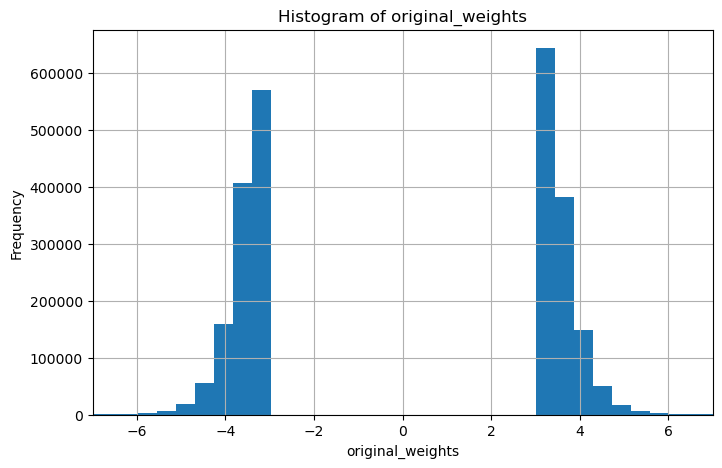

In [6]:
import matplotlib.pyplot as plt

# Plot histogram of original_weights (drop NaN)
plt.figure(figsize=(8,5))
df['original_weights'].dropna().astype(float).hist(bins=100)
plt.xlim(-7, 7)
plt.xlabel('original_weights')
plt.ylabel('Frequency')
plt.title('Histogram of original_weights')
plt.show()

In [ ]:
# Set your cutoff value
cutoff = 3.3  # Change this value as needed
# Convert original_weights to float and handle NaN values
df2 = df.copy()
df2['original_weights'] = pd.to_numeric(df2['original_weights'], errors='coerce')

# Keep rows where original_weights is either > cutoff or < -cutoff
filtered_df = df2[
    (df2['original_weights'] >= cutoff) | 
    (df2['original_weights'] <= -cutoff)
]

# Keep only rows with original_weights > cutoff
filtered_df

Coherent code

In [ ]:
# -----------------------------------------------------------
# 1.  Imports
# -----------------------------------------------------------
import pandas as pd
import torch
from torch_geometric_signed_directed.data import SignedData
from torch_geometric_signed_directed.utils.general.link_split import link_class_split

# -----------------------------------------------------------
# 2.  Load your CSV
# -----------------------------------------------------------
# adjust the path / separator as needed
# df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')
# df = df[(df['target_type'] == 'Gene') & (df['source_type'] == 'Chemical')]
# df = df.dropna(subset=["sign"]).copy()
# df["sign"] = df["sign"].astype(int)
# df = df[df["sign"].isin([-1, 1])]
# # OPTIONAL – remove self-loops or duplicate lines
# df = df[df["source"] != df["target"]].drop_duplicates(subset=["source", "target", "sign"])
# df.reset_index(inplace=True)
          


# df = filtered_df
# -----------------------------------------------------------
# 3.  Map every node ID (string or int) to a 0-based index
# -----------------------------------------------------------
all_nodes = pd.concat([df["source"], df["target"]]).unique()
node2idx   = {node: i for i, node in enumerate(all_nodes)}

src_idx = df["source"].map(node2idx).to_numpy()
dst_idx = df["target"].map(node2idx).to_numpy()

edge_index  = torch.tensor([src_idx, dst_idx], dtype=torch.long)
edge_weight = torch.tensor(df["sign"].to_numpy(), dtype=torch.float)

# -----------------------------------------------------------
# 4.  Wrap in a SignedData object
# -----------------------------------------------------------
data = SignedData(edge_index=edge_index, edge_weight=edge_weight)
data.to_unweighted()          # guarantees weights are exactly ±1

print(data)                   # quick sanity check
# e.g.  SignedData(num_nodes=12345, num_edges=161638)

# -----------------------------------------------------------
# 6.  Persist to disk (so the script can load it quickly)
# -----------------------------------------------------------
torch.save(data, "/home/vmottaqi/kg/models/kg_signed_filt_Jun22025.pt")        # single file is enough

# …or save the 'splits' dictionary too:
# torch.save({"data": data, "splits": splits}, "my_kg_signed_with_splits.pt")


Create a submsaple of the large dataset to test

In [1]:
# -----------------------------------------------------------
# Create 100K Edge Subsample for Testing
# -----------------------------------------------------------
import pandas as pd
import torch
import numpy as np
from torch_geometric_signed_directed.data import SignedData

def create_subsample_dataset(target_edges=100000, random_seed=2024):
    """
    Create a subsample of the large KG dataset with specified number of edges
    while preserving class balance (positive/negative ratio).
    """
    
    print("="*60)
    print(f"CREATING {target_edges//1000}K EDGE SUBSAMPLE")
    print("="*60)
    
    # -----------------------------------------------------------
    # 1. Load and Filter Original Data
    # -----------------------------------------------------------
    print("Loading original CSV data...")
    df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')
    df = df[(df['target_type'] == 'Gene') & (df['source_type'] == 'Chemical')]
    df = df.dropna(subset=["sign"]).copy()
    df["sign"] = df["sign"].astype(int)
    df = df[df["sign"].isin([-1, 1])]
    df = df[df["source"] != df["target"]].drop_duplicates(subset=["source", "target", "sign"])
    df.reset_index(drop=True, inplace=True)
    
    print(f"After basic filtering: {len(df):,} edges")
    
    # -----------------------------------------------------------
    # 2. Apply Weight Cutoff Filter
    # -----------------------------------------------------------
    cutoff = 3.5
    df['original_weights'] = pd.to_numeric(df['original_weights'], errors='coerce')
    filtered_df = df[
        (df['original_weights'] > cutoff) | 
        (df['original_weights'] < -cutoff)
    ].copy()
    
    print(f"After weight cutoff (|w| > {cutoff}): {len(filtered_df):,} edges")
    
    # -----------------------------------------------------------
    # 3. Create Balanced Subsample
    # -----------------------------------------------------------
    np.random.seed(random_seed)
    
    # Separate positive and negative edges
    pos_edges = filtered_df[filtered_df['sign'] == 1].copy()
    neg_edges = filtered_df[filtered_df['sign'] == -1].copy()
    
    print(f"Original distribution: {len(pos_edges):,} positive, {len(neg_edges):,} negative")
    
    # Calculate target numbers (preserve ratio or use 50/50)
    total_available = len(pos_edges) + len(neg_edges)
    
    if total_available < target_edges:
        print(f"WARNING: Only {total_available:,} edges available, using all of them")
        target_edges = total_available
        target_pos = len(pos_edges)
        target_neg = len(neg_edges)
    else:
        # Preserve original ratio
        pos_ratio = len(pos_edges) / total_available
        target_pos = int(target_edges * pos_ratio)
        target_neg = target_edges - target_pos
        
        # Ensure we don't exceed available edges
        target_pos = min(target_pos, len(pos_edges))
        target_neg = min(target_neg, len(neg_edges))
        target_edges = target_pos + target_neg
    
    print(f"Target subsample: {target_pos:,} positive, {target_neg:,} negative ({target_edges:,} total)")
    
    # Sample edges
    sampled_pos = pos_edges.sample(n=target_pos, random_state=random_seed)
    sampled_neg = neg_edges.sample(n=target_neg, random_state=random_seed)
    
    # Combine and shuffle
    subsampled_df = pd.concat([sampled_pos, sampled_neg]).sample(frac=1, random_state=random_seed).reset_index(drop=True)
    
    # -----------------------------------------------------------
    # 4. Map Nodes to Indices (Only Nodes in Subsample)
    # -----------------------------------------------------------
    print("Mapping nodes to indices...")
    all_nodes = pd.concat([subsampled_df["source"], subsampled_df["target"]]).unique()
    node2idx = {node: i for i, node in enumerate(all_nodes)}
    
    src_idx = subsampled_df["source"].map(node2idx).to_numpy()
    dst_idx = subsampled_df["target"].map(node2idx).to_numpy()
    
    edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
    edge_weight = torch.tensor(subsampled_df["sign"].to_numpy(), dtype=torch.float)
    
    # -----------------------------------------------------------
    # 5. Create SignedData Object
    # -----------------------------------------------------------
    data = SignedData(edge_index=edge_index, edge_weight=edge_weight)
    data.to_unweighted()  # Ensure weights are exactly ±1
    
    # -----------------------------------------------------------
    # 6. Print Summary Statistics
    # -----------------------------------------------------------
    print("\n" + "="*60)
    print("SUBSAMPLE DATASET SUMMARY")
    print("="*60)
    print(f"Total nodes: {data.num_nodes:,}")
    print(f"Total edges: {data.edge_index.shape[1]:,}")
    print(f"Positive edges: {(data.edge_weight > 0).sum().item():,}")
    print(f"Negative edges: {(data.edge_weight < 0).sum().item():,}")
    print(f"Average degree: {(2 * data.edge_index.shape[1]) / data.num_nodes:.1f}")
    
    # Calculate edge density
    max_edges = data.num_nodes * (data.num_nodes - 1)
    density = data.edge_index.shape[1] / max_edges
    print(f"Graph density: {density:.6f}")
    print("="*60)
    
    return data, subsampled_df

# -----------------------------------------------------------
# 7. Create and Save Multiple Subsample Sizes for Testing
# -----------------------------------------------------------
if __name__ == "__main__":
    
    # Create different subsample sizes for testing
    subsample_sizes = [100000, 50000]  # 100K, 50K, 200K
    
    for size in subsample_sizes:
        print(f"\nCreating {size//1000}K edge subsample...")
        
        try:
            data, df_subset = create_subsample_dataset(target_edges=size, random_seed=2024)
            
            # Save the PyTorch Geometric data
            output_file = f"/home/vmottaqi/kg/models/kg_signed_gene_chemical_{size//1000}k.pt"
            torch.save(data, output_file)
            print(f"✓ Saved subsample to: {output_file}")
            
            # Optionally save the DataFrame for inspection
            # csv_file = f"/home/vmottaqi/kg/models/kg_signed_gene_chemical_{size//1000}k.csv"
            # df_subset.to_csv(csv_file, index=False)
            # print(f"✓ Saved CSV to: {csv_file}")
            
        except Exception as e:
            print(f"✗ Error creating {size//1000}K subsample: {e}")
        
        print("-" * 40)
    
    print("\n🎯 RECOMMENDED TESTING ORDER:")
    print("1. Start with 50K edges to verify the model works")
    print("2. Try 100K edges if 50K works well") 
    print("3. Scale up to 200K edges to test limits")
    print("4. Use lower embedding dimensions (--in_dim 32 --out_dim 32)")


Creating 100K edge subsample...
CREATING 100K EDGE SUBSAMPLE
Loading original CSV data...


/tmp/ipykernel_819372/1274421933.py:23: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')


After basic filtering: 2,468,244 edges
After weight cutoff (|w| > 3.5): 1,061,770 edges
Original distribution: 538,238 positive, 523,532 negative
Target subsample: 50,692 positive, 49,308 negative (100,000 total)
Mapping nodes to indices...


/tmp/ipykernel_819372/1274421933.py:94: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)



SUBSAMPLE DATASET SUMMARY
Total nodes: 21,996
Total edges: 100,000
Positive edges: 50,692
Negative edges: 49,308
Average degree: 9.1
Graph density: 0.000207
✓ Saved subsample to: /home/vmottaqi/kg/models/kg_signed_gene_chemical_100k.pt
----------------------------------------

Creating 50K edge subsample...
CREATING 50K EDGE SUBSAMPLE
Loading original CSV data...


/tmp/ipykernel_819372/1274421933.py:23: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')


After basic filtering: 2,468,244 edges
After weight cutoff (|w| > 3.5): 1,061,770 edges
Original distribution: 538,238 positive, 523,532 negative
Target subsample: 25,346 positive, 24,654 negative (50,000 total)
Mapping nodes to indices...

SUBSAMPLE DATASET SUMMARY
Total nodes: 20,148
Total edges: 50,000
Positive edges: 25,346
Negative edges: 24,654
Average degree: 5.0
Graph density: 0.000123
✓ Saved subsample to: /home/vmottaqi/kg/models/kg_signed_gene_chemical_50k.pt
----------------------------------------

🎯 RECOMMENDED TESTING ORDER:
1. Start with 50K edges to verify the model works
2. Try 100K edges if 50K works well
3. Scale up to 200K edges to test limits
4. Use lower embedding dimensions (--in_dim 32 --out_dim 32)


Include node features!

In [15]:
import pandas as pd
import torch
from torch_geometric_signed_directed.data import SignedData

# -----------------------------------------------------------
# 1.  Load your CSV
# -----------------------------------------------------------
df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')
df = df[(df['target_type'] == 'Protein') & (df['source_type'] == 'Chemical')]
df = df.dropna(subset=["sign"]).copy()
df["sign"] = df["sign"].astype(int)
df = df[df["sign"].isin([-1, 1])]
df = df[df["source"] != df["target"]].drop_duplicates(subset=["source", "target", "sign"])
df.reset_index(inplace=True)

# -----------------------------------------------------------
# 2.  Create node type mapping
# -----------------------------------------------------------
# Create sets of all chemical and gene nodes
chemical_nodes = set(df['source'].unique())
gene_nodes = set(df['target'].unique())

# Create node type dictionary (0=Chemical, 1=Gene)
node_type_dict = {}
for node in chemical_nodes:
    node_type_dict[node] = 0
for node in gene_nodes:
    # If a node appears in both, prioritize Chemical type
    if node not in node_type_dict:
        node_type_dict[node] = 1

# -----------------------------------------------------------
# 3.  Map nodes to indices and create features
# -----------------------------------------------------------
all_nodes = pd.concat([df["source"], df["target"]]).unique()
node2idx = {node: i for i, node in enumerate(all_nodes)}

# Create one-hot features [Chemical, Gene]
features = []
for node in all_nodes:
    node_type = node_type_dict.get(node, 0)
    features.append([1, 0] if node_type == 0 else [0, 1])
    
features = torch.tensor(features, dtype=torch.float)

src_idx = df["source"].map(node2idx).to_numpy()
dst_idx = df["target"].map(node2idx).to_numpy()

edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
edge_weight = torch.tensor(df["sign"].to_numpy(), dtype=torch.float)

# -----------------------------------------------------------
# 4.  Create SignedData with node features
# -----------------------------------------------------------
data = SignedData(
    x=features,             # Add node features
    edge_index=edge_index, 
    edge_weight=edge_weight
)
data.to_unweighted()  # Ensure signs are exactly ±1

print(data)
print(f"Feature dimension: {data.x.shape[1]}")
print(f"Chemical nodes: {(data.x[:, 0] == 1).sum().item()}")
print(f"Protein nodes: {(data.x[:, 1] == 1).sum().item()}")



/tmp/ipykernel_785577/939776031.py:8: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv')


SignedData(x=[8832, 2], edge_index=[2, 13711], A=<COOrdinate sparse matrix of dtype 'float32'
	with 13711 stored elements and shape (8832, 8832)>
  Coords	Values
  (0, 7240)	-1.0
  (1, 7241)	-1.0
  (2, 7241)	-1.0
  (3, 7241)	-1.0
  (4, 7242)	-1.0
  (5, 7242)	-1.0
  (6, 7243)	-1.0
  (7, 7244)	-1.0
  (8, 7244)	-1.0
  (9, 7244)	-1.0
  (10, 7244)	-1.0
  (11, 7244)	-1.0
  (12, 7244)	-1.0
  (13, 7244)	-1.0
  (14, 7245)	-1.0
  (15, 7245)	-1.0
  (16, 7245)	-1.0
  (17, 7246)	1.0
  (18, 7246)	1.0
  (19, 7246)	1.0
  (20, 7246)	1.0
  (21, 7246)	1.0
  (22, 7246)	1.0
  (23, 7246)	1.0
  (24, 7246)	1.0
  :	:
  (6416, 7704)	1.0
  (6267, 7246)	1.0
  (6449, 7319)	-1.0
  (7236, 8209)	-1.0
  (6379, 7704)	1.0
  (7237, 8129)	-1.0
  (7037, 7380)	-1.0
  (6117, 8209)	-1.0
  (6546, 8130)	1.0
  (6644, 7380)	1.0
  (6849, 8775)	1.0
  (6607, 7317)	-1.0
  (7084, 7379)	1.0
  (6159, 7258)	-1.0
  (7238, 8668)	-1.0
  (6607, 7318)	-1.0
  (6611, 7704)	1.0
  (7227, 7347)	1.0
  (7239, 7316)	1.0
  (6266, 7378)	-1.0
  (7223, 7

In [16]:
# -----------------------------------------------------------
# 5.  Save to disk
# -----------------------------------------------------------
torch.save(data, "/home/vmottaqi/kg/models/kg_signed_chem_protein_nfeatures.pt")